# Simple Linear Regression for Salary Data
### Predicting Salary based on Years of Experience

## Step 1: Import Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

## Step 2: Load Dataset

In [30]:
import os
os.chdir("/Users/pawar_saloni/Downloads")  # Set correct path
print("Current directory:", os.getcwd())

Current directory: /Users/pawar_saloni/Downloads


In [31]:
df = pd.read_csv("Salary.csv")  # Exact filename with correct casing
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (35, 2)


## Step 3: Explore the Data

In [32]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [33]:
df.tail()

,YearsExperience,Salary
30,11.2,127345
31,11.5,126756
32,12.3,128765
33,12.9,135675
34,13.5,139465


In [34]:
df.describe()

,YearsExperience,Salary
count,35.000000,35.000000
mean,6.308571,83945.600000
std,3.618610,32162.673003
min,1.100000,37731.000000
25%,3.450000,57019.000000
50%,5.300000,81363.000000
75%,9.250000,113223.500000
max,13.500000,139465.000000


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  35 non-null     float64
 1   Salary           35 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 692.0 bytes


In [36]:
print("Null values:")
print(df.isnull().sum())

Null values:
YearsExperience    0
Salary             0
dtype: int64


## 
Step 4: Data Visualization

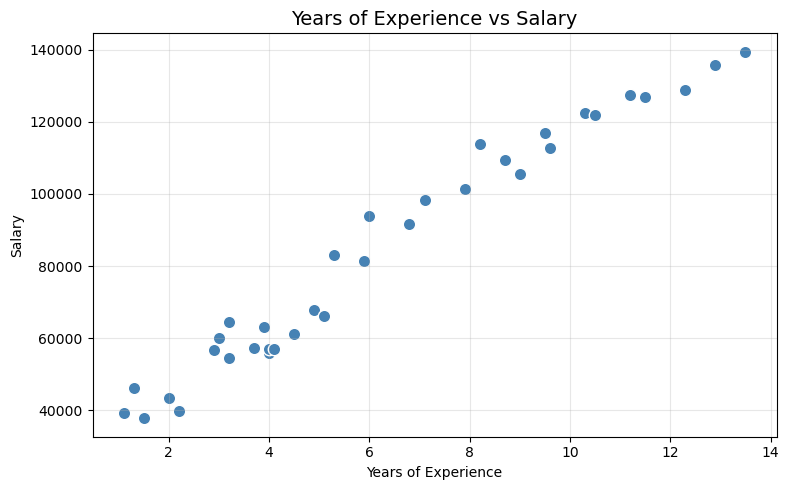

In [37]:
plt.figure(figsize=(8, 5))
plt.scatter(df['YearsExperience'], df['Salary'], color='steelblue', edgecolors='white', s=80)
plt.title('Years of Experience vs Salary', fontsize=14)
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

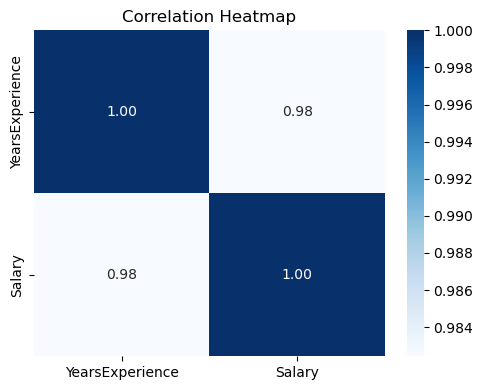

In [38]:
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Step 5: Define X and y, Split Data

In [39]:
X = df[['YearsExperience']]  # Independent variable (2D array)
y = df['Salary']              # Dependent variable

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (35, 1)
y shape: (35,)


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training set size:", X_train.shape[0])
print("Testing set size: ", X_test.shape[0])

Training set size: 24
Testing set size:  11


## Step 6: Build & Train the Model

In [41]:
LR = LinearRegression()
LR.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [42]:
m = LR.coef_[0]       # Slope
c = LR.intercept_     # Intercept

print(f"Coefficient (slope m) : {m:.4f}")
print(f"Intercept (c)         : {c:.4f}")
print(f"\nRegression Equation   : Salary = {m:.2f} * YearsExperience + {c:.2f}")

Coefficient (slope m) : 8555.3392
Intercept (c)         : 29602.0735

Regression Equation   : Salary = 8555.34 * YearsExperience + 29602.07


## Step 7: Predictions
### y = mx + c

In [43]:
y_pred = LR.predict(X_test)

In [44]:
# Compare Actual vs Predicted
comparison = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': np.round(y_pred, 2),
    'Difference': np.round(y_test.values - y_pred, 2)
})
comparison.reset_index(drop=True, inplace=True)
comparison

,Actual Salary,Predicted Salary,Difference
0,116969,110877.80,6091.20
1,57081,64678.96,-7597.96
2,109431,104033.52,5397.48
3,98273,90344.98,7928.02
4,67938,71523.24,-3585.24
5,121872,119433.14,2438.86
6,93940,80934.11,13005.89
7,56957,63823.43,-6866.43
8,64445,56979.16,7465.84
9,66029,73234.30,-7205.30


## Step 8: Evaluation Metrics

In [45]:
# R² Score (Accuracy)
accuracy = LR.score(X_test, y_test)
print(f"R² Score (Accuracy): {accuracy:.4f}  →  {accuracy*100:.2f}%")

R² Score (Accuracy): 0.9171  →  91.71%


In [46]:
# MAE - Mean Absolute Error
mae = metrics.mean_absolute_error(y_test, y_pred)
print(f"MAE  (Mean Absolute Error) : {mae:.2f}")

MAE  (Mean Absolute Error) : 6513.64


In [47]:
# MSE - Mean Squared Error
mse = metrics.mean_squared_error(y_test, y_pred)
print(f"MSE  (Mean Squared Error)  : {mse:.2f}")

MSE  (Mean Squared Error)  : 49647591.15


In [48]:
# RMSE - Root Mean Squared Error
rmse = np.sqrt(mse)
print(f"RMSE (Root Mean Sq Error)  : {rmse:.2f}")

RMSE (Root Mean Sq Error)  : 7046.10


In [49]:
# Summary of all metrics
print("="*40)
print("       MODEL EVALUATION SUMMARY")
print("="*40)
print(f"  R² Score : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  MAE      : {mae:.2f}")
print(f"  MSE      : {mse:.2f}")
print(f"  RMSE     : {rmse:.2f}")
print("="*40)

       MODEL EVALUATION SUMMARY
  R² Score : 0.9171 (91.71%)
  MAE      : 6513.64
  MSE      : 49647591.15
  RMSE     : 7046.10


## Step 9: Visualize Regression Line

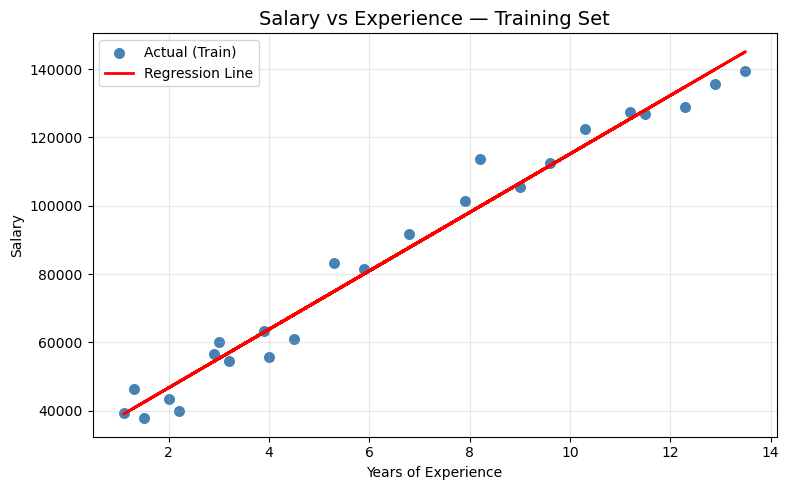

In [50]:
# Training Set
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='steelblue', label='Actual (Train)', edgecolors='white', s=80)
plt.plot(X_train, LR.predict(X_train), color='red', linewidth=2, label='Regression Line')
plt.title('Salary vs Experience — Training Set', fontsize=14)
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

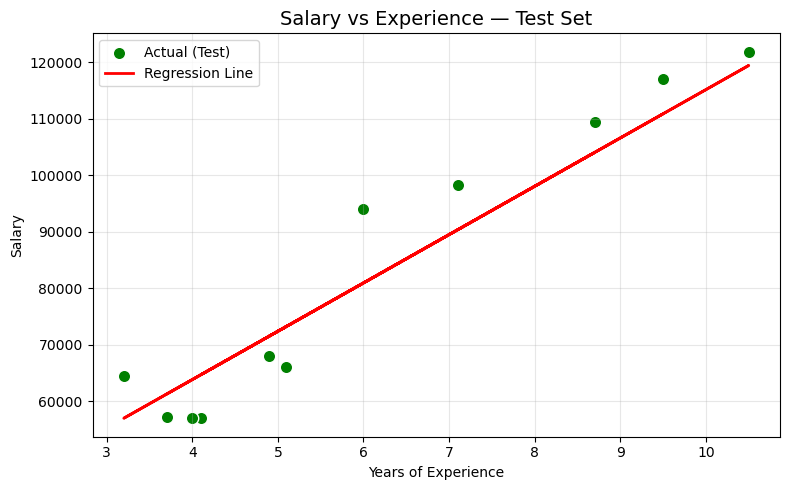

In [51]:
# Test Set
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='green', label='Actual (Test)', edgecolors='white', s=80)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Salary vs Experience — Test Set', fontsize=14)
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

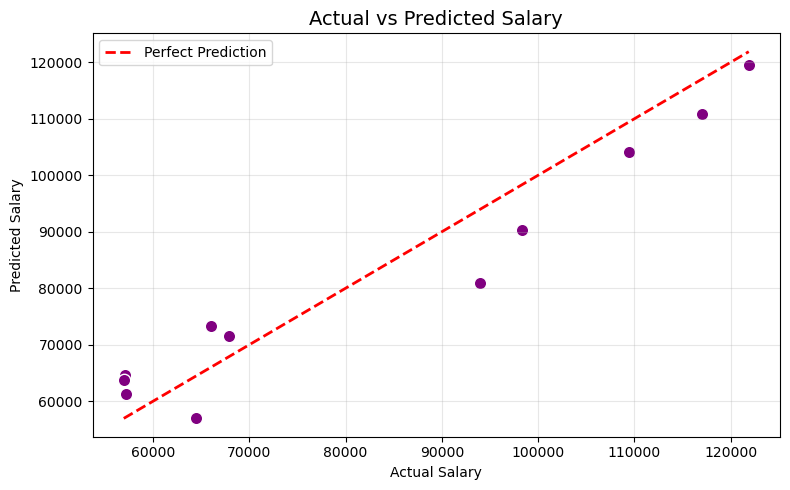

In [52]:
# Actual vs Predicted Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='purple', edgecolors='white', s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Salary', fontsize=14)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()